### Librerias e importaciones

In [1]:
import sys
sys.path.append("../src")


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost
import lightgbm
import catboost


from preprocessing import preprocesamiento_pre_split, preprocesamiento_post_split, onehot_encoding
from data_splitting import train_val_split
from plots import eda_visualizacion_suvs, plot_antiguedad_km_vs_precio, plot_dispersion_por_marca

In [2]:
#IGNORAR ESTA CELDA
%load_ext autoreload
%autoreload 2

### EDA

**Preprocessing**

In [3]:
data = pd.read_csv('../data/pf_suvs.csv')

In [4]:
display(pd.DataFrame({
    "nulos": data.isnull().sum(),
    "unicos": data.nunique()
}).query("nulos > 0"))


,nulos,unicos
Color,389,70
Transmisión,15,4
Motor,38,271
Con cámara de retroceso,13563,2


In [5]:
print("\n Dataset ALEATORIO")
print(data.sample(5))

print("\n -------- RESUMEN - ESTADISTICOS E INFO -------- \n" )
print("\n DATA INFO")
print(data.info())



 Dataset ALEATORIO
       Unnamed: 0       Marca         Modelo     Año               Versión  \
13662       13662   Chevrolet        Tracker  2025.0      1.2 Turbo Ltz At   
16558       16558      Nissan          Kicks  2020.0           1.6 Advance   
16613       16613  Volkswagen           Taos  2025.0  1.4 250 Tsi Highline   
17116       17116        Jeep       Renegade  2018.0     1.8 Sport At Plus   
7040         7040      Toyota  Corolla Cross  2022.0          1.8 Xei Ecvt   

        Color Tipo de combustible  Puertas Transmisión Motor  \
13662    Gris               Nafta      5.0  Automática   1.2   
16558  Blanco               Nafta      5.0      Manual   1.6   
16613    Gris               Nafta      5.0  Automática   1.4   
17116   Negro               Nafta      5.0  Automática   1.8   
7040   Blanco       Híbrido/Nafta      5.0  Automática   1.8   

      Tipo de carrocería Con cámara de retroceso Kilómetros  \
13662                SUV                     NaN        0.0   


In [6]:
summary = pd.DataFrame({
    "dtype": data.dtypes,
    "nulos": data.isnull().sum(),
    "unicos": data.nunique()
})
summary

,dtype,nulos,unicos
Unnamed: 0,int64,0,18254
Marca,str,0,47
Modelo,str,0,137
Año,float64,0,40
Versión,str,0,2072
Color,str,389,70
Tipo de combustible,str,0,8
Puertas,float64,0,7
Transmisión,str,15,4
Motor,str,38,271


In [7]:
print("\n DATA DESCRIPCION " )
data.describe()


 DATA DESCRIPCION 


,Unnamed: 0,Año,Puertas,Precio
count,18254.000000,18254.000000,18254.000000,1.825400e+04
mean,9126.500000,2042.796209,18.167306,1.760162e+07
std,5269.620242,3217.260996,891.766121,1.720810e+07
min,0.000000,1981.000000,2.000000,1.110000e+02
25%,4563.250000,2016.000000,5.000000,3.190000e+04
50%,9126.500000,2019.000000,5.000000,1.720000e+07
75%,13689.750000,2024.000000,5.000000,2.995000e+07
max,18253.000000,436694.000000,60252.000000,3.495000e+08


*El análisis exploratorio permitió detectar la existencia de valores faltantes en diversas variables descriptivas del vehículo, entre ellas Color, Transmisión, Motor y Con cámara de retroceso. Debido a que estas variables pueden influir significativamente en el valor de mercado de una SUV, se optó por imputar los datos faltantes en lugar de descartar las observaciones correspondientes, preservando así el tamaño de la muestra disponible para entrenamiento.*

*Por otra parte, se observó que gran parte de los atributos del dataset se encuentran representados mediante variables categóricas de tipo texto. Dado que los algoritmos de aprendizaje supervisado utilizados trabajan sobre representaciones numéricas, será necesario transformar dichas variables mediante One-Hot Encoding, generando una codificación binaria que permita incorporar esta información al modelo sin introducir relaciones artificiales entre categorías*

***PREPROCESAMIENTO: Limpieza de datos necesaria para no afectar el entrenamiento del modelo.***

**Justificacion de desiciones tomadas**


1. ` La variable Unnamed`: 0 actúa únicamente como identificador de cada publicación y no aporta información relevante para la predicción del precio, por lo que fue eliminada.
2. `Cambio de moneda a USD`Para garantizar la comparabilidad entre observaciones y evitar que la moneda introduzca sesgos en los modelos, todos los precios fueron convertidos a dólares utilizando un único tipo de cambio de referencia y se eliminio la columna ya que no aportaba informacion.
3. Se eliminó columnas(features) como `Unnamed`, `Tipo de carroceria`, `Titulo`, `Version`

4. `Imputacion de Puertas`: se observaron valores inconsistentes en la variable Puertas. Dado que el conjunto de datos contiene exclusivamente SUVs, se decidió homogeneizar los valores restantes utilizando cinco puertas como valor por defecto

In [8]:
display(data["Puertas"].value_counts().sort_index())

Puertas
2.0           10
3.0          105
4.0          399
5.0        17731
6.0            3
7.0            2
60252.0        4
Name: count, dtype: int64

5. `Motor`: presentaba únicamente 38 valores faltantes (menos del 0.3% del dataset). Debido a su baja proporción, se optó por eliminar dichas observaciones en lugar de imputarlas para evitar introducir ruido artificial. A su vez , los datos estaban en str se cambiaron a valor numerico.


    La variable Motor se encontraba almacenada como texto y presentaba múltiples formatos de escritura, por ejemplo "2.0 TSI", "1.6 THP", "2.8 TD" o "1.3 Turbo". Con el objetivo de obtener una variable numérica consistente, se extrajo la cilindrada del motor y se transformó a formato float.

In [9]:
nulos_motor = data["Motor"].isna().sum()
total = len(data)

print(f"Nulos en Motor: {nulos_motor}")
print(f"Total de registros: {total}")
print(f"Porcentaje de nulos: {100*nulos_motor/total:.3f}%")

Nulos en Motor: 38
Total de registros: 18254
Porcentaje de nulos: 0.208%


In [10]:
print(data["Motor"].unique().tolist())

['1.5', '2.0 L 230 CV  350 TSI', '1.4', '2.4', '1.5 TURBO', '2.0', '3.6', '1.8', '1.0', '1.3', '1.2 TURBO', '1.2', '1.6', 'Nafta 2.0 (148cv) + Electrico (184.5cv)', '3.0', '2.2', '2.5', '1', '2.5l Hibrida', '2.8', '2.7', 'TURBOALIMENTADO', 'TURBO DIESEL INYECCION', '4.8', '2.9', '1.3T', 'INYECCION MULTI PUNTO', nan, 'diesel', '4.4', '3.0 440HP', '2.0 hurrican 4 272 cv 400nm', '6.4', '5.2', '1.5t', '1.4 TFSI', '2.3', '4.7', '2.0 TDI 140CV', '3.7', '3.2', '1500', '3.8', '1.3 TURBO', '4.5', '3', '2', '2.0 TURBO', '4.0 Nafta', '1.8L', '192 HP', '1.6 Naftero', '5.0', '1.5 TURBO 185 HP', 'P8 (408hp)', '1,3 t 175 cv 270 Nm', '1.6 Turbo', '4.2', '4.0', '1.0 tsi', '1.5 16V', '1.0 200 TSI', '1.8 de 140 hp', '2.0 350TSI', '3.5', '1.3L', '1.3 Turbo', '1.0 TURBO', '1.3 TURBO NAFTA 175CV AT9', 'Motor naftero 1.8 105 CV 161 Nm', '1.0 3 CILINDROS', 'v8 302', '3.3 V6 TD 304cv 700 NM de torque', '1.5 turbo', 'TURBO 2 LITROS', '1.6 MSI Nafta', '1.0T', '6.1', '2500', '2.4L', 'V6 PLUG IN HYBRID 460HP', '2.

In [11]:
motor_extraido = (
    data["Motor"]
    .str.extract(r'(\d+[.,]\d+)')[0]
)

perdidos = data[
    data["Motor"].notna() &
    motor_extraido.isna()
]

print(len(perdidos))
display(perdidos["Motor"].value_counts().head(50))

429


Motor
INYECCION MULTI PUNTO                         157
TURBOALIMENTADO                                82
1                                              67
2                                              41
TURBO DIESEL INYECCION                         10
Turbo 140 CV                                    4
1600                                            3
1500                                            2
192 HP                                          2
V6 PLUG IN HYBRID 460HP                         2
v8                                              2
300 HP                                          2
Turbo con 205 cv                                2
NAFTA                                           2
T8 462hp Plug In Hybrid                         2
Chevrolet                                       2
16000                                           2
Eléctrico                                       2
2000                                            2
Turbo 156 CV                                

Durante este proceso se detectaron 429 registros (2.35% del conjunto de datos) cuyo contenido no permitía identificar una cilindrada válida, incluyendo descripciones genéricas como "Turboalimentado", "Inyección multipunto" o valores evidentemente erróneos. Debido a su baja proporción respecto del total de observaciones, dichos registros fueron eliminados del análisis.

6. `Kilometros`: Se transformó a valor numérico para garantizar un tratamiento consistente. Además se crea feature ¨0 Km¨ que indica vehiculo nuevo o usado.

7. `Descripcion` : contiene texto libre que no puede ser utilizado directamente por modelos de regresion tradicionales. Se construyó un score basado en palabras clave positivas y negativas asociadas al estado general del vehículo, documentación, mantenimiento y equipamiento. El resultado se transformó en una escala numérica entre 1 y 10.

8. `Marcas`:Se unifican las muestras de Marcas para evitar duplucados , y/o reconocimiento erroneo de una Marca. 

In [12]:
print(data["Marca"].unique().tolist())

['Ford', 'Volkswagen', 'Jeep', 'BAIC', 'Kia', 'Hyundai', 'Porsche', 'Peugeot', 'Fiat', 'Chevrolet', 'Citroën', 'BMW', 'Audi', 'Honda', 'Nissan', 'Mercedes-Benz', 'Renault', 'Suzuki', 'Toyota', 'D.S.', 'Chery', 'Daihatsu', 'SsangYong', 'Dodge', 'JAC', 'Land Rover', 'Alfa Romeo', 'Haval', 'Volvo', 'Lifan', 'Mini', 'D·S', 'Mitsubishi', 'Range Rover', 'Hiunday', 'Jetour', 'GWM', 'KAIYI', 'Lexus', 'Isuzu', 'Rrenault', 'Subaru', 'Jetur', 'DS AUTOMOBILES', 'hiunday', 'Jaguar', 'Vol']


8. `Año`: Considerando que se tiene 1 valor extremo, claro outlier o error de carga, se elimina la muestra ya que no aporta informacion ni se pierde al no tenerla.

In [13]:
display(pd.DataFrame(data['Año'].describe()))

,Año
count,18254.000000
mean,2042.796209
std,3217.260996
min,1981.000000
25%,2016.000000
50%,2019.000000
75%,2024.000000
max,436694.000000


In [14]:
print((data["Año"] > 2025).sum()) 
print(data[data["Año"] > 2025]["Año"].unique()) 

1
[436694.]


In [15]:
data_pre = preprocesamiento_pre_split(data)
print('Tamaño final del dataset -> ', data_pre.shape)

Original:           18254
Post filtro año:    18253
Post motor nulos:   18215
Post tratar motor:  18215
Post puertas:       18205
Tamaño final del dataset ->  (18205, 14)


In [16]:
display(pd.DataFrame({
    "nulos": data.isnull().sum(),
     "unicos": data_pre.nunique()
}).query("nulos > 0"))


,nulos,unicos
Color,389.0,69.0
Con cámara de retroceso,13563.0,2.0
Motor,38.0,97.0
Transmisión,15.0,4.0


In [17]:
print("Original:          ", data.shape[0])
print("Post preprocessing:", data_pre.shape[0])
print("Diferencia:        ", data.shape[0] - data_pre.shape[0])


Original:           18254
Post preprocessing: 18205
Diferencia:         49


In [18]:
colores_originales = set(data["Color"].dropna().unique())
colores_post = set(data_pre["Color"].dropna().unique())
print("Colores perdidos:", colores_originales - colores_post)


Colores perdidos: {'Azul claro'}


**NUEVO DATASET**

In [19]:
print("\n Dataset NUEVO, ALEATORIO")
print(data_pre.sample(5))

print("\n -------- RESUMEN - ESTADISTICOS E INFO -------- \n" )
print("\n data_pre INFO")
print(data_pre.info())
print("\n data_pre DESCRIPCION " )
print(data_pre.describe())


 Dataset NUEVO, ALEATORIO
           Marca        Modelo     Año     Color Tipo de combustible  Puertas  \
14009       Jeep       Compass  2019.0      Gris               Nafta      5.0   
9034     Hyundai        Tucson  2013.0  Plateado               Nafta      5.0   
6337        Audi  q5 sportback  2025.0     Negro               Nafta      5.0   
11359  Chevrolet       Tracker  2018.0  Plateado             Híbrido      5.0   
3227   Chevrolet       Tracker  2018.0    Blanco               Nafta      5.0   

      Transmisión Motor Con cámara de retroceso  Kilómetros         Precio  \
14009  Automática   2.4                     NaN     85000.0   35948.451277   
9034   Automática   2.0                     NaN    170000.0   21478.634411   
6337   Automática   2.0                      Sí         0.0  108000.000000   
11359      Manual     1                      No     75000.0   22224.734343   
3227   Automática   1.8                     NaN    101652.0   20913.407190   

      Tipo de ven

In [20]:
summary = pd.DataFrame({
    "dtype": data_pre.dtypes,
    "nulos": data_pre.isnull().sum(),
    "unicos": data_pre.nunique()
})
summary

,dtype,nulos,unicos
Marca,str,0,41
Modelo,str,0,136
Año,float64,0,38
Color,str,389,69
Tipo de combustible,str,0,8
Puertas,float64,0,2
Transmisión,str,11,4
Motor,object,0,97
Con cámara de retroceso,str,13541,2
Kilómetros,float64,431,2120


**VISUALIZACION DEL EDA HASTA AHORA**

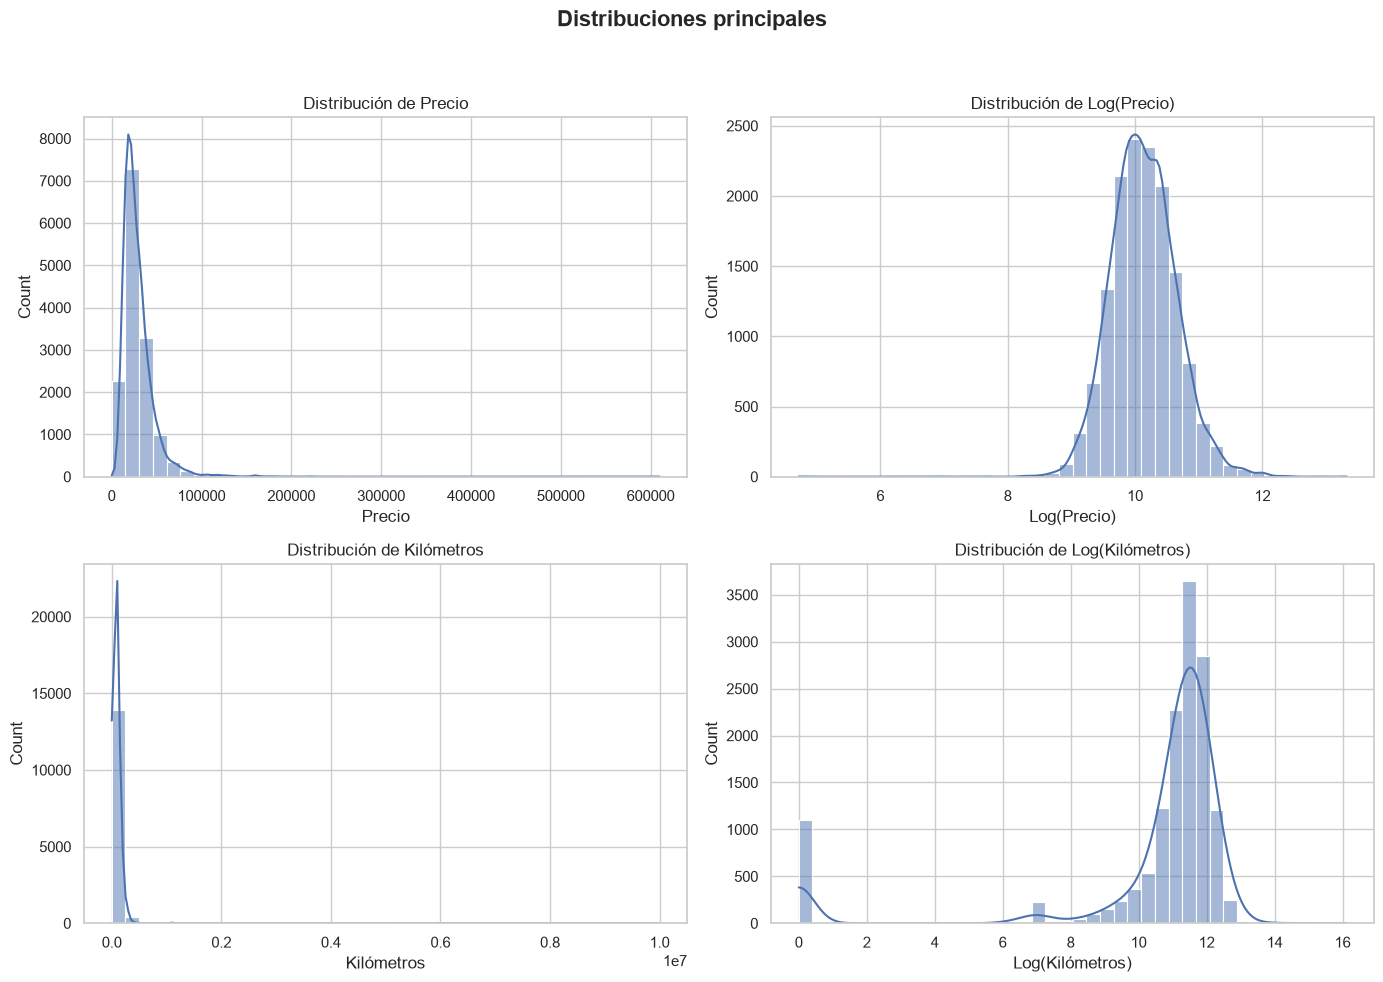

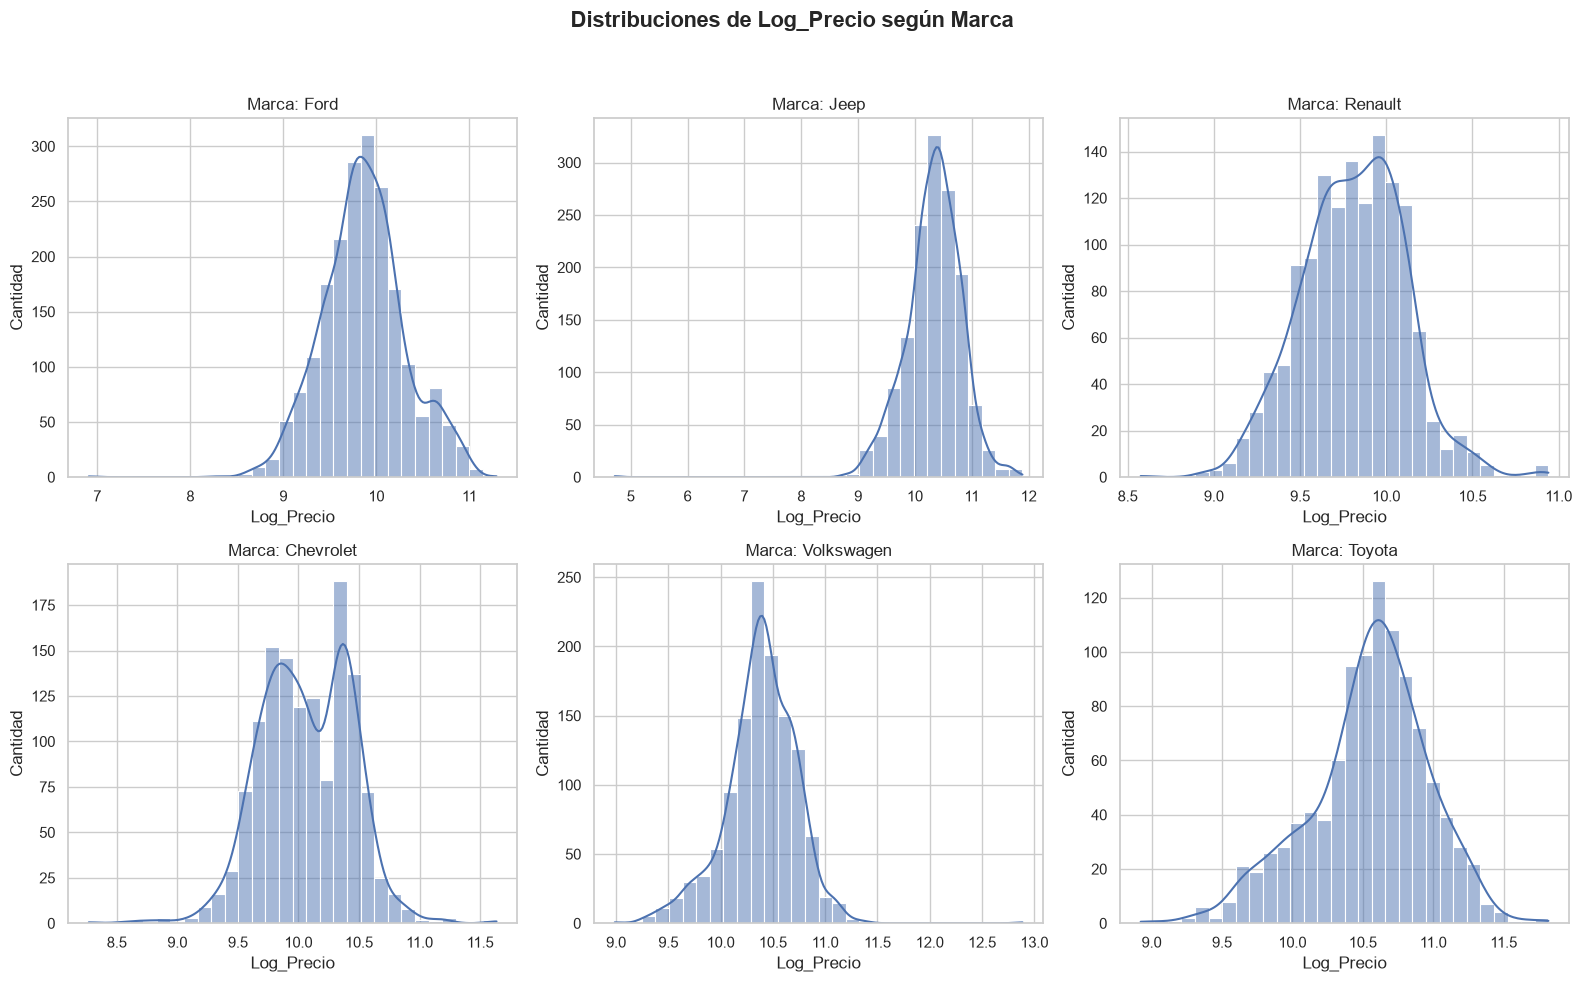

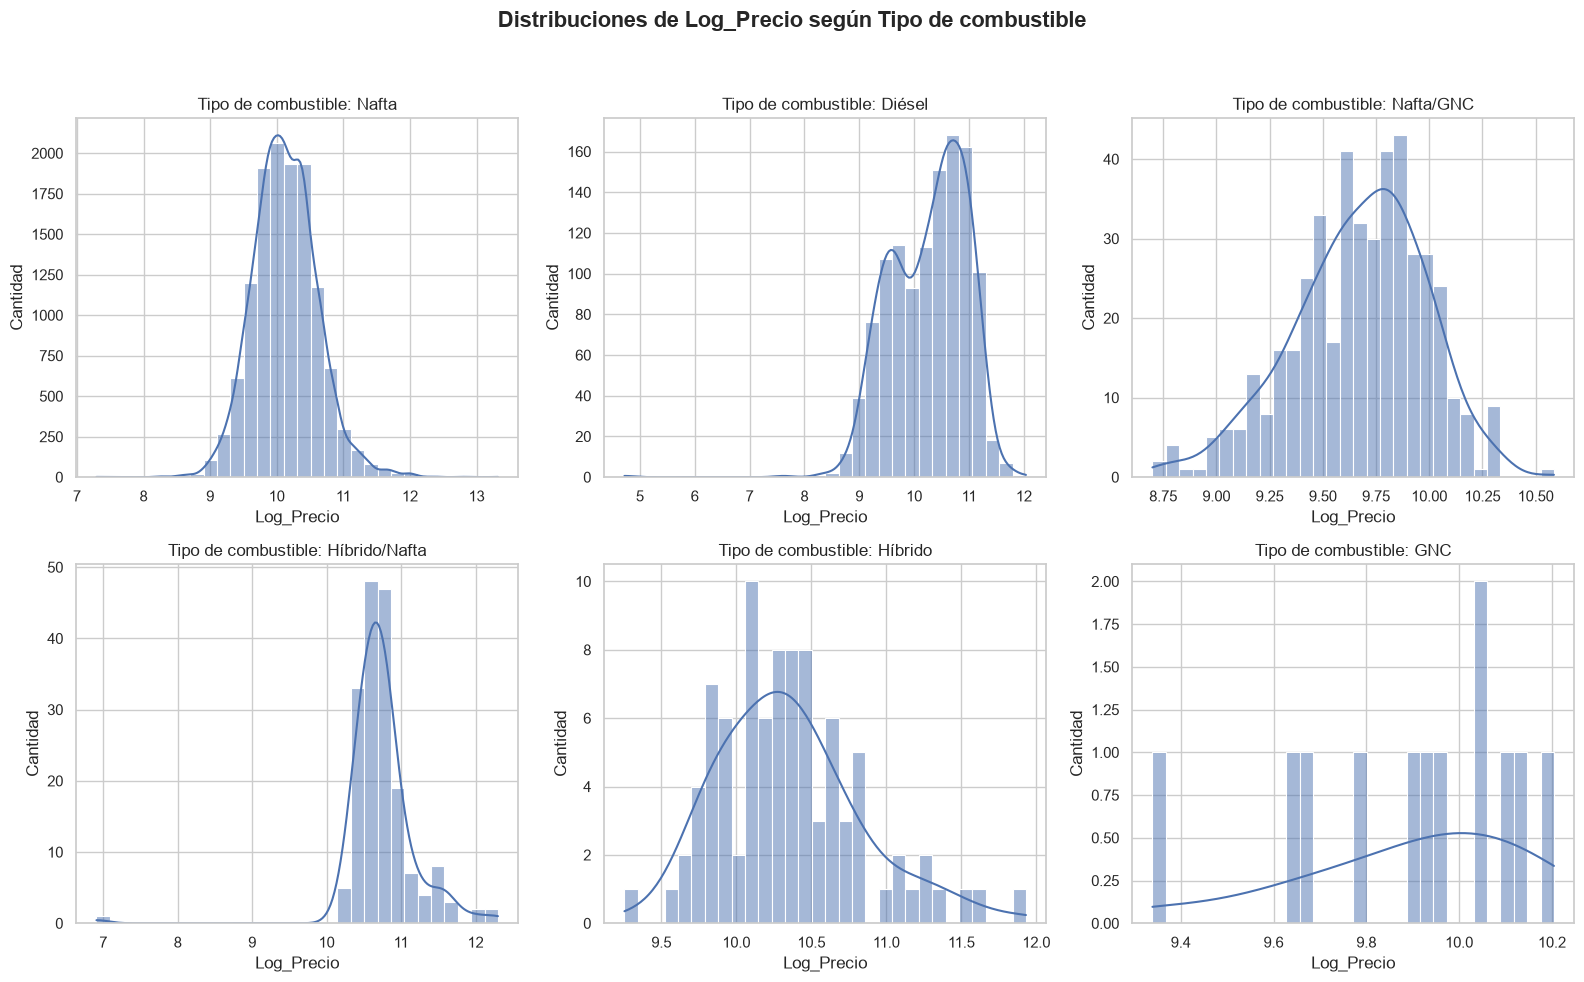

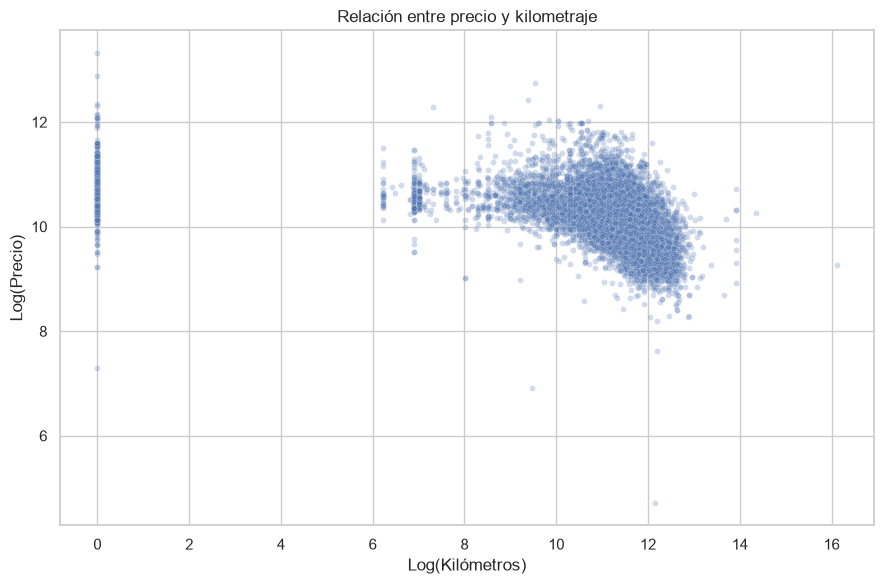

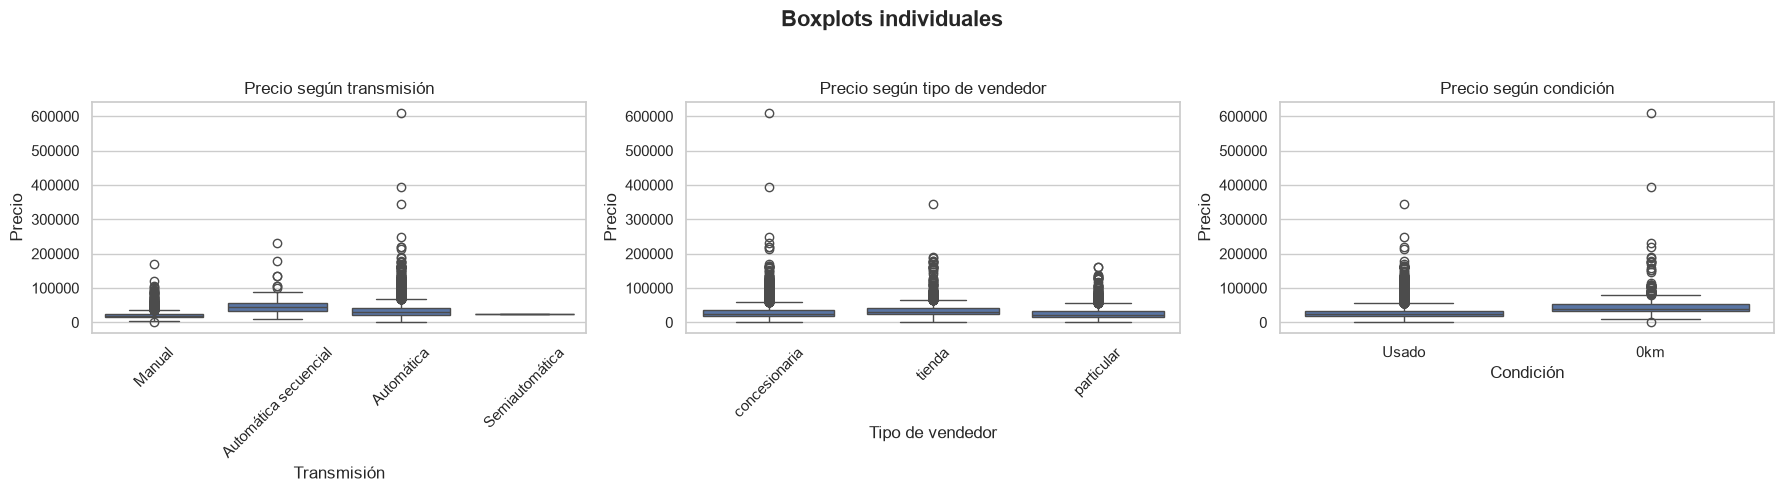

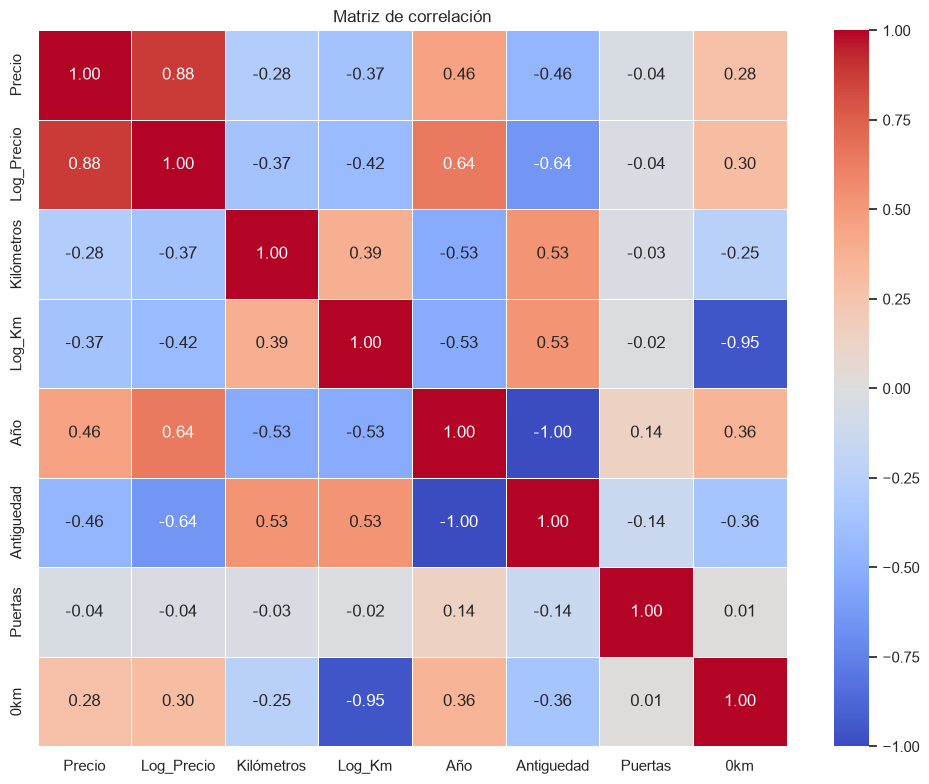

In [21]:
#Plots
eda_visualizacion_suvs(data_pre)

Para terminar con el ***preprocesamiento de datos***, se aplica el split para poder obtener la moda calculada sobre el conjunto de train, y asi poder completar los valores faltantes de las features "color", "transmision", "camara"  evitando el data leakage.

In [22]:
train, val = train_val_split(data_pre)

Tamaño conjunto de entrenamiento -> (14564, 14), 
Tamaño conjunto de validación -> (3641, 14)


In [23]:
print(train.columns.tolist())


['Marca', 'Modelo', 'Año', 'Color', 'Tipo de combustible', 'Puertas', 'Transmisión', 'Motor', 'Con cámara de retroceso', 'Kilómetros', 'Precio', 'Tipo de vendedor', '0km', 'Score Descripción']


In [24]:
#Preprocessing post split using the train parameters
train, val = preprocesamiento_post_split(train, val)

0
0
post crear features 
0
0


In [25]:
#One-Hot Encoding sobre las columnas con baja cardinalidad
columnas_oh = ['Tipo de combustible', 'Tipo de vendedor', 'Transmisión', 'Con cámara de retroceso']
train, val = onehot_encoding(train, val, columnas_oh)

In [26]:
print('Final del preprocesamiento sobre Entrenamiento')
summary = pd.DataFrame({
    "dtype": train.dtypes,
    "nulos": train.isnull().sum(),
    "unicos": train.nunique()
})
summary

Final del preprocesamiento sobre Entrenamiento


,dtype,nulos,unicos
Marca,str,0,41
Modelo,str,0,136
Año,float64,0,38
Color,str,0,64
Puertas,float64,0,2
Motor,object,0,88
Kilómetros,float64,0,1837
Precio,float64,0,2587
0km,int64,0,2
Score Descripción,int64,0,10


In [27]:
print('Final del preprocesamiento sobre Validación')
summary = pd.DataFrame({
    "dtype": val.dtypes,
    "nulos": val.isnull().sum(),
    "unicos": val.nunique()
})
summary

Final del preprocesamiento sobre Validación


,dtype,nulos,unicos
Marca,str,0,35
Modelo,str,0,113
Año,float64,0,33
Color,str,0,32
Puertas,float64,0,2
Motor,object,0,53
Kilómetros,float64,0,773
Precio,float64,0,1194
0km,int64,0,2
Score Descripción,int64,0,8


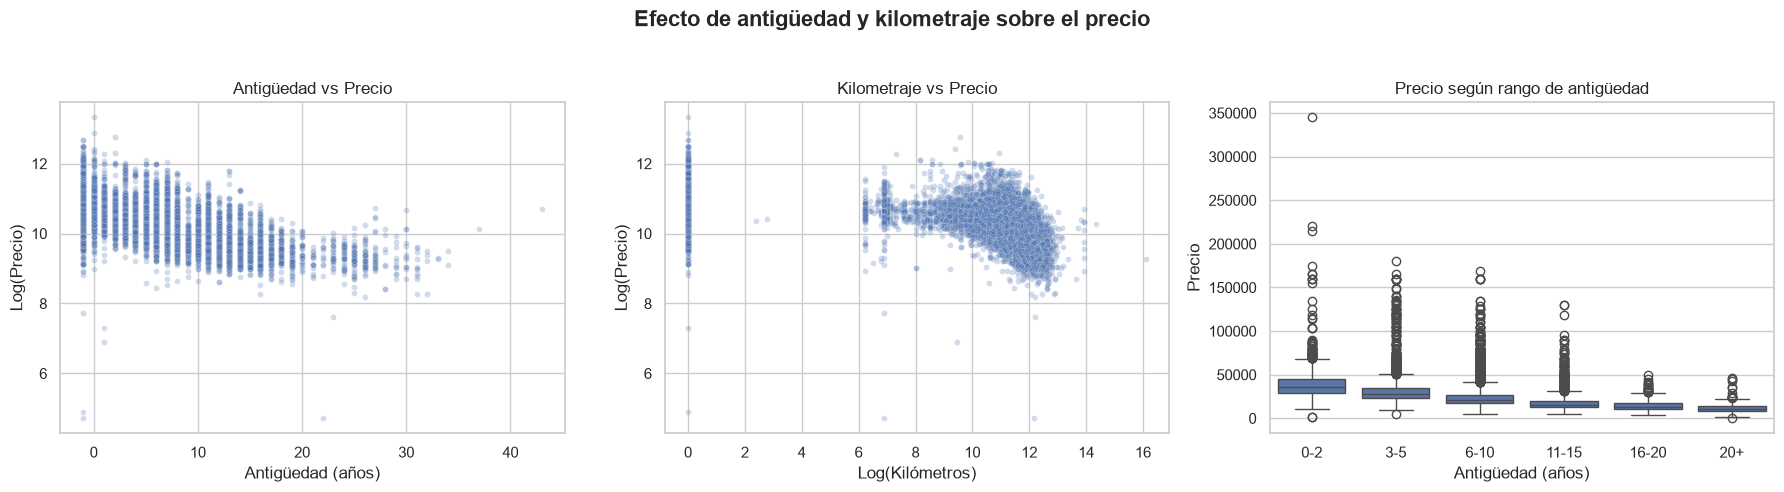

In [28]:
data_visualizacion = pd.concat([train, val], ignore_index = True)
data_visualizacion = data_visualizacion[data_visualizacion['Antiguedad'] <= 50]
plot_antiguedad_km_vs_precio(data_visualizacion, target = "Precio")

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">

Podemos observar, tanto para la **antiguedad** como para el **kilometraje** una clara tendencia. El primer gráfico muestra que a mayor años de uso, el precio del vehículo (en escala logarítmica) decrece de manera consistente. Los autos de 0-2 años concentran los precios más altos, rondando entre los e^10 y e^12 USD, mientras que los de más de 20 años, se ubican en rangos más bajos.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
El segundo gráfico confirma lo esperado: a mayor log(Km), menor log(Precio). Los vehículos 0km tienen precios más elevados, lo cual es consistente con la realidad; y la dispersión aumenta a medida que sube el kilometraje, lo que genera el desgaste del vehículo, impactando negativamente en su precio.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
El boxplot por rangos de antiguedad refuerza ambas observaciones: la mediana de precio decae progresivamente, reduciéndose la dispersión en autos más antiguos. Los outliers más extremos se localizan en el rango de los 0-2 años, correspondiendo posiblemente, a vehículos de alta gama 0km.
</p>

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">
Con esto se deja en evidencia la importancia de ambos features en relación con el precio para la generalización del modelo predictivo a entrenar.
</p>

In [29]:
#Definimos que las marcas con mas de 35 muestras sean las validas para calcular el Coeficiente de Variacion
marcas_validas = data_pre['Marca'].value_counts()
marcas_validas = marcas_validas[marcas_validas >= 35].index
data_filtrado = data_pre[data_pre['Marca'].isin(marcas_validas)]

cv = data_filtrado.groupby('Marca')['Precio'].agg(['std', 'mean'])
cv["cv"] = cv["std"] / cv["mean"]
cv.sort_values("cv")

,std,mean,cv
Marca,,,
BAIC,8168.709746,33949.043510,0.240617
Fiat,7811.699722,29043.587015,0.268965
Citroën,7760.194150,27100.748636,0.286346
Dodge,5045.540464,16580.144385,0.304312
Nissan,10444.089423,30131.155682,0.346621
Volkswagen,13723.981059,37244.423138,0.368484
Chery,6718.083270,17427.838247,0.385480
Peugeot,10686.032925,27385.913429,0.390202
Renault,8061.083332,20578.220193,0.391729


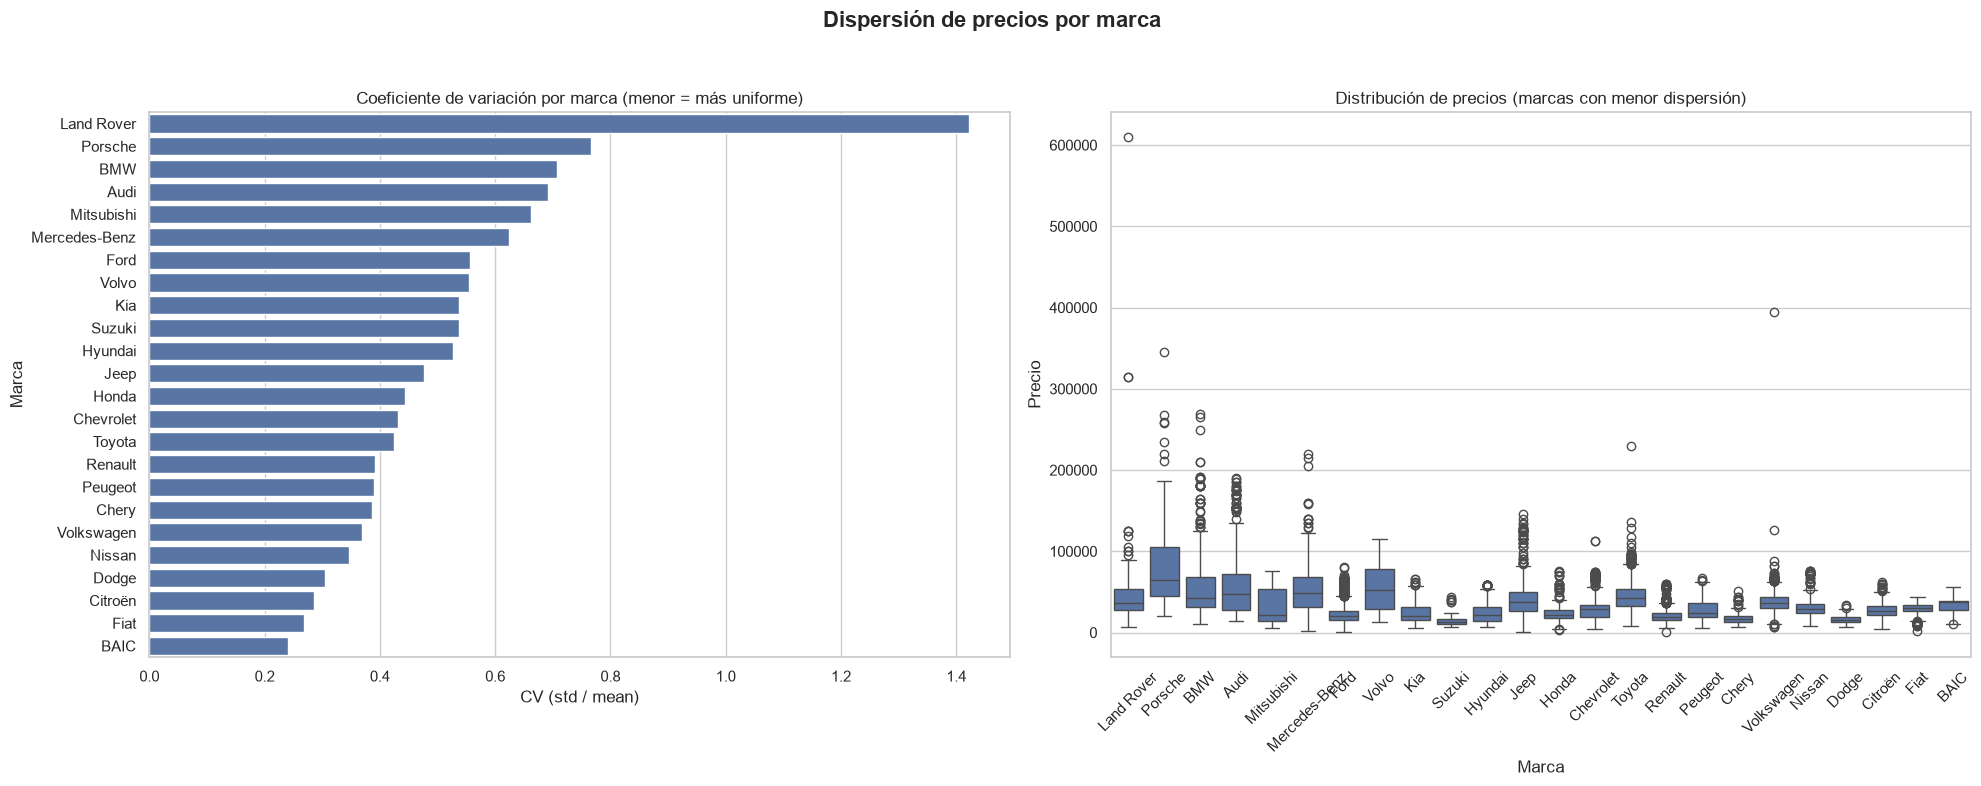

In [30]:
plot_dispersion_por_marca(data_pre)

<p style="text-align: justify; text-justify: inter-word; font-size: 16px;">

Las marcas con mayor dispersión resultan ser **Land Rover**, **Porsche** y **BMW**, tres marcas de lujo, lo cual explica este resultado: ofrecen modelos que van desde vehículos de entrada hasta vehículos de alta gama, lo que genera una gran variabilidad de precios dentro de sus modelos. El boxplot confirma esto con cajas amplias (particularmente en el caso de Porsche) y outliers con valores extremos.

En el extremo opuesto, encontramos a **BAIC**, **Fiat** y **Citroën**, que presentan la menor dispersión entre las marcas más predominantes del dataset. Se presentan como marcas con modelos más accesibles, los cuales se concentran en un rango de precio similar entre sí, y con un catálogo más acotado. Sus boxplots muestran cajas compactas y pocos outliers.

Lo observado a partir de la información provista coincide con lo esperable para este tipo de marcas, donde se tienen tanto modelos exclusivos como de segmento medio.
</p>

### MODELOS

### Comparación entre modelos

### Final Model